# train.curated.v002-5 のバイト長分布（ByT5 max_length 目安）

- 元ノート: `notebooks/EDA/train.curated.v002-4-2_バイト長分布.ipynb`
- 変更点: 入力データを `train.curated.v002-5.xlsx` に差し替え、出力CSV名も `v002-5` 用に分離した。
- 目的: ByT5 の `max_length` が **UTF-8 byte（≒token数）上限**として効くので、
  `transliteration(+prefix)` と `translation` の **バイト長分布**を可視化して上限候補を決める。
- 注意: 厳密な token 数は tokenizer に依存するが、ByT5 は byte-level なので byte 長がほぼ近似になる。

このノートで出すもの:

1. 分位点（p50/p90/p95/p98/p99/max）
2. ヒストグラム（線形/対数）
3. ECDF（累積分布）
4. `max_length` 候補ごとの truncation 率
5. 最長サンプルのプレビュー（先頭/末尾）

出力 CSV（`PROCESS-DATA/train.curated.v002-4-2_バイト長分布*.csv`）には、行ごとに **`アッカド語転写_英訳文`** 列を含める（内容は `"アッカド語転写": …` と `"英訳文": …` を改行で連結した1セル）。


In [1]:
from __future__ import annotations

from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = Path("/Users/koshidatatsuo/python/kaggle/Deep_Past_Challenge/data/curated/deep-past-initiative-machine-translation/train/train.curated.v002-5.xlsx")
OUTPUT_FULL_PATH = Path("PROCESS-DATA/train.curated.v002-5_バイト長分布.csv")
OUTPUT_TRUNCATED_PATH = Path("PROCESS-DATA/train.curated.v002-5_バイト長分布縮約.csv")
SOURCE_PREFIX = "translate Akkadian to English: "  # ByT5 学習で付ける想定（31 bytes）
CANDIDATE_MAX_LENGTHS = [256, 384, 512, 768, 1024, 1152, 1280, 1408, 1536, 1792, 2048]

print("DATA_PATH:", DATA_PATH)
print("OUTPUT_FULL_PATH:", OUTPUT_FULL_PATH)
print("OUTPUT_TRUNCATED_PATH:", OUTPUT_TRUNCATED_PATH)
print("SOURCE_PREFIX bytes:", len(SOURCE_PREFIX.encode("utf-8")))


DATA_PATH: /Users/koshidatatsuo/python/kaggle/Deep_Past_Challenge/data/curated/deep-past-initiative-machine-translation/train/train.curated.v002-5.xlsx
OUTPUT_FULL_PATH: PROCESS-DATA/train.curated.v002-5_バイト長分布.csv
OUTPUT_TRUNCATED_PATH: PROCESS-DATA/train.curated.v002-5_バイト長分布縮約.csv
SOURCE_PREFIX bytes: 31


In [2]:
# openpyxl が必要（ローカル/Jupyter では通常利用可能な想定）
df = pd.read_excel(DATA_PATH)
print("rows:", len(df))
print("columns:", df.columns.tolist())

def pick_col(preferred: str, fallback_substrings: list[str]) -> str:
    if preferred in df.columns:
        return preferred
    lower = {c: str(c).lower() for c in df.columns}
    for sub in fallback_substrings:
        hits = [c for c, lc in lower.items() if sub in lc]
        if hits:
            return hits[0]
    raise KeyError(f"Column not found. preferred={preferred}, columns={df.columns.tolist()}")

SRC_COL = pick_col("transliteration", ["translit", "akk", "source"])
TGT_COL = pick_col("translation", ["translat", "eng", "target"])

print("SRC_COL:", SRC_COL)
print("TGT_COL:", TGT_COL)
df.head(3)


rows: 1589
columns: ['Unnamed: 0', 'oare_id', 'label', 'excavation_no', 'transliteration', 'pdf', 'translation', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']
SRC_COL: transliteration
TGT_COL: translation


,Unnamed: 0,oare_id,label,excavation_no,transliteration,pdf,translation,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,0.0,01cc1406-fc42-4252-aeae-6b4538b069c5,Cuneiform Tablet Kt 92/k 239 (AKT 5 57),Kt 92/k 239,17 GÍN KÙ.BABBAR ší-im e-ma-ri-im 30 ma-na URU...,5,"17 shekels of silver, the price of a donkey, 3...",1.0,NaN,NaN
1,1.0,017c5be4-f459-4ef5-a045-5933e79c01f9,Cuneiform Tablet Kt 92/k 245 (AKT 5 69),Kt 92/k 245,ṭup-pu-um ša 10 ma-na KÙ.BABBAR ša PÚZUR-a-šur...,5,A tablet about 10 minas of silver of Puzur-Ass...,1.0,NaN,NaN
2,2.0,f52c21e6-5eb4-4a73-a539-c2686cc935b8,Cuneiform Tablet Kt 89/k 289 (AKT 5 76),Kt 89/k 289,a-na ku-li-a qí-bi4-ma um-ma a-šùr-i-mì-tí-ma ...,5,"Say to Kuliya, thus Aššur-imittī: In Šalatuwar...",1.0,NaN,NaN


In [3]:
def byte_len(text: str) -> int:
    return len(text.encode("utf-8"))

src_raw = df[SRC_COL].fillna("").astype(str)
tgt_raw = df[TGT_COL].fillna("").astype(str)

df_len = df.copy()
df_len["src_bytes_raw"] = src_raw.map(byte_len)
df_len["src_bytes_with_prefix"] = (SOURCE_PREFIX + src_raw).map(byte_len)
df_len["tgt_bytes"] = tgt_raw.map(byte_len)

# CSV 用: 転写・英訳を日本語ラベル付きで1セルにまとめる（1行目・2行目は改行で区切る）
LABELED_PAIR_COL = "アッカド語転写_英訳文"
df_len[LABELED_PAIR_COL] = (
    '"アッカド語転写": ' + src_raw + '\n"英訳文": ' + tgt_raw
)

cols = [c for c in ["oare_id", "excavation_no", "pdf", SRC_COL, TGT_COL, LABELED_PAIR_COL, "src_bytes_raw", "src_bytes_with_prefix", "tgt_bytes"] if c in df_len.columns]
df_len[cols].head(3)


,oare_id,excavation_no,pdf,transliteration,translation,アッカド語転写_英訳文,src_bytes_raw,src_bytes_with_prefix,tgt_bytes
0,01cc1406-fc42-4252-aeae-6b4538b069c5,Kt 92/k 239,5,17 GÍN KÙ.BABBAR ší-im e-ma-ri-im 30 ma-na URU...,"17 shekels of silver, the price of a donkey, 3...","""アッカド語転写"": 17 GÍN KÙ.BABBAR ší-im e-ma-ri-im 3...",509,540,486
1,017c5be4-f459-4ef5-a045-5933e79c01f9,Kt 92/k 245,5,ṭup-pu-um ša 10 ma-na KÙ.BABBAR ša PÚZUR-a-šur...,A tablet about 10 minas of silver of Puzur-Ass...,"""アッカド語転写"": ṭup-pu-um ša 10 ma-na KÙ.BABBAR ša ...",468,499,441
2,f52c21e6-5eb4-4a73-a539-c2686cc935b8,Kt 89/k 289,5,a-na ku-li-a qí-bi4-ma um-ma a-šùr-i-mì-tí-ma ...,"Say to Kuliya, thus Aššur-imittī: In Šalatuwar...","""アッカド語転写"": a-na ku-li-a qí-bi4-ma um-ma a-šùr-...",580,611,596


In [4]:
def summarize(vals: np.ndarray) -> pd.Series:
    quantiles = [0.50, 0.90, 0.95, 0.98, 0.99]
    out = {f"p{int(q * 100)}": int(np.quantile(vals, q)) for q in quantiles}
    out["max"] = int(np.max(vals))
    out["mean"] = float(np.mean(vals))
    return pd.Series(out)

src_with_prefix = df_len["src_bytes_with_prefix"].to_numpy()
tgt = df_len["tgt_bytes"].to_numpy()

summary = pd.DataFrame({
    "transliteration(+prefix)": summarize(src_with_prefix),
    "translation": summarize(tgt),
})

export_cols = [c for c in ["oare_id", "excavation_no", "pdf", SRC_COL, TGT_COL, LABELED_PAIR_COL, "src_bytes_raw", "src_bytes_with_prefix", "tgt_bytes"] if c in df_len.columns]
df_len[export_cols].to_csv(OUTPUT_FULL_PATH, index=False)
df_len[(df_len["src_bytes_with_prefix"] > (1024 - len(SOURCE_PREFIX.encode("utf-8")))) | (df_len["tgt_bytes"] > (1024 - len(SOURCE_PREFIX.encode("utf-8"))))][export_cols].to_csv(OUTPUT_TRUNCATED_PATH, index=False)

summary


,transliteration(+prefix),translation
p50,450.00000,418.000000
p90,1117.00000,1069.000000
p95,1461.00000,1404.000000
p98,1828.00000,1763.000000
p99,2451.00000,2401.000000
max,4570.00000,4061.000000
mean,578.76652,536.047199


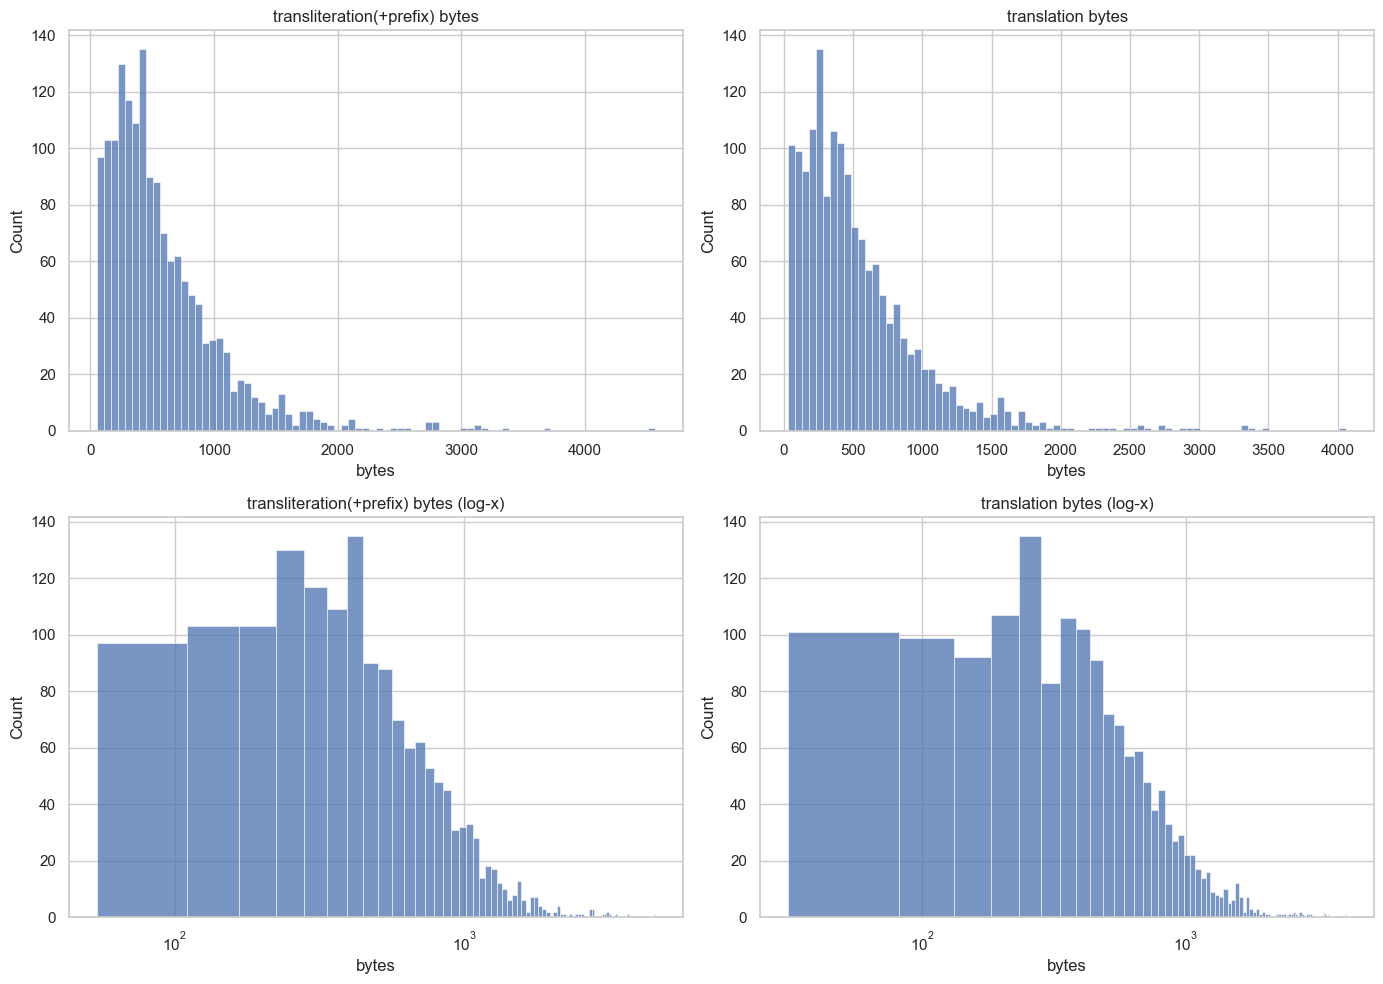

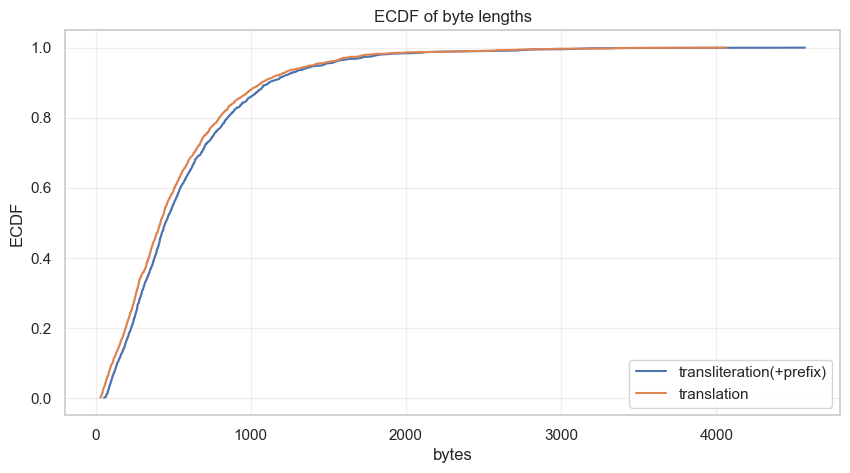

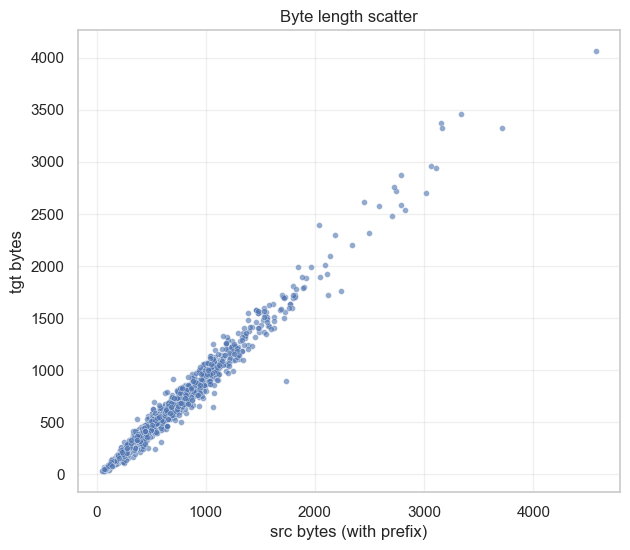

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_len["src_bytes_with_prefix"], bins=80, ax=axes[0, 0])
axes[0, 0].set_title("transliteration(+prefix) bytes")
axes[0, 0].set_xlabel("bytes")

sns.histplot(df_len["tgt_bytes"], bins=80, ax=axes[0, 1])
axes[0, 1].set_title("translation bytes")
axes[0, 1].set_xlabel("bytes")

sns.histplot(df_len["src_bytes_with_prefix"], bins=80, ax=axes[1, 0])
axes[1, 0].set_xscale("log")
axes[1, 0].set_title("transliteration(+prefix) bytes (log-x)")
axes[1, 0].set_xlabel("bytes")

sns.histplot(df_len["tgt_bytes"], bins=80, ax=axes[1, 1])
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("translation bytes (log-x)")
axes[1, 1].set_xlabel("bytes")

plt.tight_layout()
plt.show()

def plot_ecdf(vals: np.ndarray, label: str) -> None:
    ordered = np.sort(vals)
    ratio = np.arange(1, len(ordered) + 1) / len(ordered)
    plt.plot(ordered, ratio, label=label)

plt.figure(figsize=(10, 5))
plot_ecdf(src_with_prefix, "transliteration(+prefix)")
plot_ecdf(tgt, "translation")
plt.xlabel("bytes")
plt.ylabel("ECDF")
plt.title("ECDF of byte lengths")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 6))
sns.scatterplot(x=df_len["src_bytes_with_prefix"], y=df_len["tgt_bytes"], s=18, alpha=0.6)
plt.xlabel("src bytes (with prefix)")
plt.ylabel("tgt bytes")
plt.title("Byte length scatter")
plt.grid(True, alpha=0.3)
plt.show()


In [6]:
def trunc_rate(vals: np.ndarray, max_length: int) -> float:
    return float(np.mean(vals > max_length))

rows = []
for max_length in CANDIDATE_MAX_LENGTHS:
    rows.append({
        "max_length": max_length,
        "src_trunc_rate": trunc_rate(src_with_prefix, max_length),
        "tgt_trunc_rate": trunc_rate(tgt, max_length),
    })

pd.DataFrame(rows).style.format({
    "src_trunc_rate": "{:.1%}",
    "tgt_trunc_rate": "{:.1%}",
})


,max_length,src_trunc_rate,tgt_trunc_rate
0,256,76.2%,71.1%
1,384,59.5%,54.4%
2,512,43.6%,39.6%
3,768,24.4%,21.6%
4,1024,13.3%,11.3%
5,1152,9.4%,8.2%
6,1280,7.0%,6.3%
7,1408,5.3%,4.8%
8,1536,4.1%,3.8%
9,1792,2.4%,1.9%


In [7]:
ID_COL = "oare_id" if "oare_id" in df_len.columns else None
LABEL_COL = "label" if "label" in df_len.columns else None

def preview_text(text: str, head: int = 220, tail: int = 220) -> str:
    text = str(text)
    if len(text) <= head + tail + 10:
        return text
    return text[:head] + " ... [snip] ... " + text[-tail:]

def show_top(df_: pd.DataFrame, sort_col: str, n: int = 10) -> pd.DataFrame:
    cols = [c for c in [ID_COL, LABEL_COL, sort_col, SRC_COL, TGT_COL] if c is not None and c in df_.columns]
    top = df_.sort_values(sort_col, ascending=False).head(n).copy()
    if SRC_COL in top.columns:
        top[SRC_COL] = top[SRC_COL].map(preview_text)
    if TGT_COL in top.columns:
        top[TGT_COL] = top[TGT_COL].map(preview_text)
    return top[cols]

print("Top by src_bytes_with_prefix")
display(show_top(df_len, "src_bytes_with_prefix", n=10))

print("Top by tgt_bytes")
display(show_top(df_len, "tgt_bytes", n=10))


Top by src_bytes_with_prefix


,oare_id,label,src_bytes_with_prefix,transliteration,translation
767,1c428f5b-15b5-463a-8e27-f9b2f0d858fc,Cuneiform Tablet Kt 94/k 1605 (AKT 6b 491),4570,ša 4 ma-na KÙ.BABBAR ša en-na-sú-in a-na a-bi-...,As to the 4 minas of silver that Enna-Suen owe...
883,991eef40-f139-4206-90ed-7fb45648b197,Cuneiform Tablet Kt 94/k 1177 (AKT 6b 464),3708,16 ma-na KÙ.BABBAR ṣa-ru-pá-am i-ṣé-er i-ku-ni...,16 minas of refined silver owed by Ikūnum son ...
522,adb0573b-20fb-469d-8343-0ace8e2489e0,Cuneiform Tablet Kt 94/k 839 (AKT 6a 75),3337,um-ma a-šùr-ma-lik ù ša-lim-a-šur a-na ša-lim-...,From Aššur-malik and Šalim-Aššur to Šalim-Aššu...
523,64f3382c-cb81-41af-99c9-36854585b747,Cuneiform Tablet Kt 94/k 841 (AKT 6a 76),3162,um-ma a-šùr-ma-lik ša-lim-a-šur ù ì-lí-a-ma a-...,"From Aššur-malik, Šalim-Aššur and Iliya to Šal..."
53,dff850c8-ccd4-44a9-9994-2834ca832a6d,Cuneiform Tablet Kt 92/k 195 (AKT 5 50),3152,<gap> na <gap> PÚZUR-a-šùr DUMU a-ḫu-wa-qar iš...,"<gap> Puzur-Aššur(?), son of Ahu-waqar <gap> b..."
554,71f57ebe-13be-4594-a9d2-bb780768e856,Cuneiform Tablet Kt 94/k 842 (AKT 6a 109),3111,a-na {d}MAR.TU-ba-ni a-šùr-i-mì-tí ṣí-lu-lu šu...,"To Amurrum-bāni, Aššur-imittī, Ṣilūlu, Šu-Kūbu..."
57,937e71fb-57c8-46c0-afbc-48f9429886e4,Cuneiform Tablet Kt 92/k 196 (AKT 5 51),3063,0.5 ma-na KÙ.BABBAR ta-ad-mì-iq-tám ša a-lá-ḫi...,"For 0.5 mina of silver, a loan by teh alahhinn..."
556,d0e6d8b8-2fb3-4d4f-a307-50b639ed2128,Cuneiform Tablet Kt 94/k 917 (AKT 6a 110),3012,a-na ší-ip-ri ša a-lim{ki} ù kà-ri-im kà-ni-iš...,To the envoys of the City and the plenary asse...
715,cbfb79f1-b5c9-4f85-99e0-eb44dca75171,Cuneiform Tablet Kt 94/k 584b (AKT 6a 267),2820,<gap> ša-ma <gap>-dí-na <gap> tí <gap> šál-ma-...,<gap> that Šalim-Aššur left behind <gap> let u...
713,092043d6-49a6-40cd-b867-5771e4babd95,Cuneiform Tablet Kt 94/k 1171 (AKT 6a 264),2785,ra-bi-ṣú-um ša É šál-ma-a-šùr a-ba-ba iṣ-ba-at...,The attorney of Šalim-Aššur's firm Ababa seize...


Top by tgt_bytes


,oare_id,label,tgt_bytes,transliteration,translation
767,1c428f5b-15b5-463a-8e27-f9b2f0d858fc,Cuneiform Tablet Kt 94/k 1605 (AKT 6b 491),4061,ša 4 ma-na KÙ.BABBAR ša en-na-sú-in a-na a-bi-...,As to the 4 minas of silver that Enna-Suen owe...
522,adb0573b-20fb-469d-8343-0ace8e2489e0,Cuneiform Tablet Kt 94/k 839 (AKT 6a 75),3457,um-ma a-šùr-ma-lik ù ša-lim-a-šur a-na ša-lim-...,From Aššur-malik and Šalim-Aššur to Šalim-Aššu...
53,dff850c8-ccd4-44a9-9994-2834ca832a6d,Cuneiform Tablet Kt 92/k 195 (AKT 5 50),3372,<gap> na <gap> PÚZUR-a-šùr DUMU a-ḫu-wa-qar iš...,"<gap> Puzur-Aššur(?), son of Ahu-waqar <gap> b..."
883,991eef40-f139-4206-90ed-7fb45648b197,Cuneiform Tablet Kt 94/k 1177 (AKT 6b 464),3327,16 ma-na KÙ.BABBAR ṣa-ru-pá-am i-ṣé-er i-ku-ni...,16 minas of refined silver owed by Ikūnum son ...
523,64f3382c-cb81-41af-99c9-36854585b747,Cuneiform Tablet Kt 94/k 841 (AKT 6a 76),3322,um-ma a-šùr-ma-lik ša-lim-a-šur ù ì-lí-a-ma a-...,"From Aššur-malik, Šalim-Aššur and Iliya to Šal..."
57,937e71fb-57c8-46c0-afbc-48f9429886e4,Cuneiform Tablet Kt 92/k 196 (AKT 5 51),2961,0.5 ma-na KÙ.BABBAR ta-ad-mì-iq-tám ša a-lá-ḫi...,"For 0.5 mina of silver, a loan by teh alahhinn..."
554,71f57ebe-13be-4594-a9d2-bb780768e856,Cuneiform Tablet Kt 94/k 842 (AKT 6a 109),2941,a-na {d}MAR.TU-ba-ni a-šùr-i-mì-tí ṣí-lu-lu šu...,"To Amurrum-bāni, Aššur-imittī, Ṣilūlu, Šu-Kūbu..."
46,630b0dbe-3124-44ba-bd08-5b03c38ad771,Cuneiform Tablet Kt 92/k 197 (AKT 5 43),2871,KIŠIB en-nam-a-šur DUMU um-ma-sá a-šur-DÙL DUM...,"Seal of Ennam-Aššur, son of Ummassa. Aššur-ṣul..."
1458,9598a20e-df54-4ca1-a231-b53046a62190,Cuneiform Tablet Kt 94/k 1268 (AKT 6e 1078),2760,6 ma-na KÙ.BABBAR ṣa-ru-pá-am KI ku-lá-ba šu-p...,"6 minas of refined silver is owed by Kulaba, Š..."
561,07a52b72-c4d6-4aa2-8d1c-2e3ba0024509,Cuneiform Tablet Kt 94/k 840 (AKT 6a 115),2724,a-na ša-lim-a-šùr qí-bi-ma um-ma {d}IM.GAL-ma ...,To Šalim-Aššur from Adad-rabi: as to the table...
